In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class NNclass:
  def GELU(self, x):
    return 0.5 * x * (1 + np.tanh(np.sqrt(2/np.pi) *(x + 0.044715 * x**3)))
  def dGELU(self, x):
    tanh_term = np.tanh(np.sqrt(2/np.pi)*(x+0.044715*x**3))
    left = 0.5*(1+tanh_term)
    right = (0.5*x*(1-tanh_term**2)*np.sqrt(2/np.pi)*(1+3*0.044715*x**2))
    return left + right
  def predict(self,Xpredict):
    factivlayers = [Xpredict]
    fneuronlayers = []
    for i in range(len(self.nnarchitecture)-2):
      fneuronlayers.append(np.dot(factivlayers[i],self.weights[i]) + self.bias[i])
      factivlayers.append(self.GELU(fneuronlayers[-1]))
    fneuronlayers.append(np.dot(factivlayers[-1],self.weights[-1]) + self.bias[-1])
    expmatrix = np.exp(fneuronlayers[-1]-np.max(fneuronlayers[-1],axis=1,keepdims=True))
    row_sums = np.sum(expmatrix, axis=1)[:, None]
    fYpredicted = expmatrix / row_sums
    return fYpredicted,fneuronlayers,factivlayers
  def targetpredict(self,Xpredict):
    ymat = self.predict(Xpredict)[0]
    idx = np.argmax(ymat,axis=1)
    return self.classes[idx]
  def accuracy(self,Ypredict,Ytest):
    return np.mean(Ypredict == Ytest)
  def precision(self,Ypredict,Ytest):
    precdict = dict()
    for i in range(len(self.classes)):
      binY = (Ytest == self.classes[i]).astype(int)
      binYpredict = (Ypredict == self.classes[i]).astype(int)
      TP = np.sum(binY*binYpredict)
      FP = np.sum(binYpredict) - TP
      precdict[f"Precision class {self.classes[i]}"] = float(TP/(TP+FP))
    return precdict
  def recall(self,Ypredict,Ytest):
    recdict = dict()
    for i in range(len(self.classes)):
      binY = (Ytest == self.classes[i]).astype(int)
      binYpredict = (Ypredict == self.classes[i]).astype(int)
      TP = np.sum(binY*binYpredict)
      FN = np.sum(binY) - TP
      recdict[f"Recall class {self.classes[i]}"] = float(TP/(TP+FN))
    return recdict
  def f1score(self,Ypredict,Ytest):
    f1dict = dict()
    for i in range(len(self.classes)):
      binY = (Ytest == self.classes[i]).astype(int)
      binYpredict = (Ypredict == self.classes[i]).astype(int)
      TP = np.sum(binY*binYpredict)
      FP = np.sum(binYpredict) - TP
      FN = np.sum(binY) - TP
      precision = TP/(TP+FP)
      recall = TP/(TP+FN)
      f1dict[f"F1 Score class {self.classes[i]}"] = float(2*precision*recall/(precision+recall))
    return f1dict
  def confusionmatrix(self,Ypredict,Ytest):
    cmatrix = np.zeros((len(self.classes), len(self.classes)), dtype=int)
    for i in range(len(self.classes)):
      binY = (Ytest == self.classes[i]).astype(int)
      for j in range(len(self.classes)):
        binYpredict = (Ypredict == self.classes[j]).astype(int)
        cmatrix[i][j] = np.sum(binY*binYpredict)
    sns.heatmap(cmatrix, annot=True, fmt='d', cmap='Blues',xticklabels=self.classes,yticklabels=self.classes)
    plt.title("Confusion Matrix")
    plt.ylabel("Actual")
    plt.xlabel("Predcited")
    plt.show()
    return cmatrix
  def fit(self,Xtrain,Ytrain,lrate=0.05,epoch = 7000,batchsize = 16):
    #init
    self.classes = np.unique(Ytrain)
    hidencount = np.random.randint((len(self.classes)+Xtrain.shape[1])//2, Xtrain.shape[1])
    rng = np.random.default_rng()
    #random architecture
    #self.nnarchitecture = np.concatenate(([Xtrain.shape[1]], np.random.randint(len(self.classes), Xtrain.shape[1]+1, hidencount),[len(self.classes)]))
    self.nnarchitecture = np.array([Xtrain.shape[1],256,128,64,32,len(self.classes)])
    print("NN archutecture ::",self.nnarchitecture)
    self.weights = []
    self.bias = []
    rng = np.random.default_rng()
    for i in range(1,len(self.nnarchitecture)):
      n,m = self.nnarchitecture[i-1],self.nnarchitecture[i],
      wmatrix = rng.normal(0,np.sqrt(2/n),size=(n,m))
      #wmatrix = rng.uniform(-0.5,0.5,size=(n, m))
      bvector = rng.uniform(-0.5,0.5,size=m)
      self.weights.append(wmatrix)
      self.bias.append(bvector)
    #Y matrix
    Ymatrix = np.eye(len(self.classes))[np.searchsorted(self.classes,Ytrain)]
    objcount = Xtrain.shape[0]
    #train
    oldloss = np.inf
    for iter in range(epoch):
      #forward
      indices = rng.choice(Xtrain.shape[0], size=batchsize, replace=False)
      Xbatch = Xtrain[indices]
      Ybatch = Ymatrix[indices]
      Ypredicted,neuronlayers,activlayers = self.predict(Xbatch)
      Loss = -np.sum(Ybatch*np.log(Ypredicted)) / batchsize
      if abs(Loss-oldloss)<1e-6:
        print(iter)
        break
      oldloss = Loss
      #back
      oldweights = copy.deepcopy(self.weights)
      oldbias = copy.deepcopy(self.bias)
      localgradient = (Ypredicted - Ybatch)/batchsize
      self.weights[-1] = oldweights[-1] - lrate*np.dot(activlayers[-1].T,localgradient)
      self.bias[-1] = oldbias[-1] - lrate*np.sum(localgradient,axis=0)
      for i in range(-2,-len(self.weights)-1,-1):
        localgradient = (localgradient @ (oldweights[i+1]).T)*self.dGELU(neuronlayers[i])
        self.weights[i] = oldweights[i] - lrate*np.dot(activlayers[i].T,localgradient)
        self.bias[i] = oldbias[i] - lrate*np.sum(localgradient,axis=0)
      del neuronlayers,activlayers,localgradient,oldweights,oldbias
      lrate = lrate * 0.999
    print("Model Trained")


In [ ]:
from tensorflow.keras.datasets import mnist

(Xtrain,Ytrain),(Xtest,Ytest) = mnist.load_data()

Xtrain = Xtrain.reshape(60000,784)/255
Xtest = Xtest.reshape(10000,784)/255

In [ ]:
obj = NNclass()
obj.fit(Xtrain,Ytrain)

NN archutecture :: [784 256 128  64  32  10]
Model Trained


In [ ]:
Ypredict = obj.targetpredict(Xtest)

In [ ]:
accuracy = obj.accuracy(Ypredict,Ytest)
print("Accuracy ::",accuracy)
print("------------")
precision = obj.precision(Ypredict,Ytest)
recall = obj.recall(Ypredict,Ytest)
f1score = obj.f1score(Ypredict,Ytest)
for i in precision:
  print(i,precision[i])
print("------------")
for i in recall:
  print(i,recall[i])
print("------------")
for i in f1score:
  print(i,f1score[i])

Accuracy :: 0.9514
Precision class 0 0.9583333333333334
Precision class 1 0.9754816112084063
Precision class 2 0.9467570183930301
Precision class 3 0.9358600583090378
Precision class 4 0.9387550200803213
Precision class 5 0.951276102088167
Precision class 6 0.947584789311408
Precision class 7 0.9651741293532339
Precision class 8 0.9442724458204335
Precision class 9 0.9471007121057986
Recall class 0 0.9857142857142858
Recall class 1 0.9814977973568282
Recall class 2 0.9476744186046512
Recall class 3 0.9534653465346534
Recall class 4 0.9521384928716904
Recall class 5 0.9192825112107623
Recall class 6 0.9624217118997912
Recall class 7 0.943579766536965
Recall class 8 0.9394250513347022
Recall class 9 0.9226957383548068
F1 Score class 0 0.971830985915493
F1 Score class 1 0.9784804567413262
F1 Score class 2 0.9472154963680388
F1 Score class 3 0.9445806768023539
F1 Score class 4 0.9453993933265925
F1 Score class 5 0.935005701254276
F1 Score class 6 0.9549456240290005
F1 Score class 7 0.95425

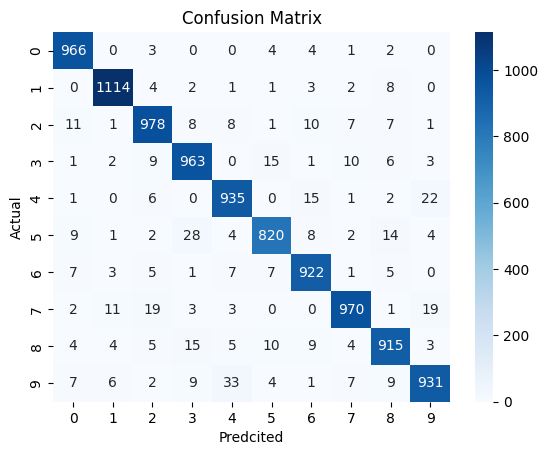

In [ ]:
conf = obj.confusionmatrix(Ypredict,Ytest)

Errors :: 486


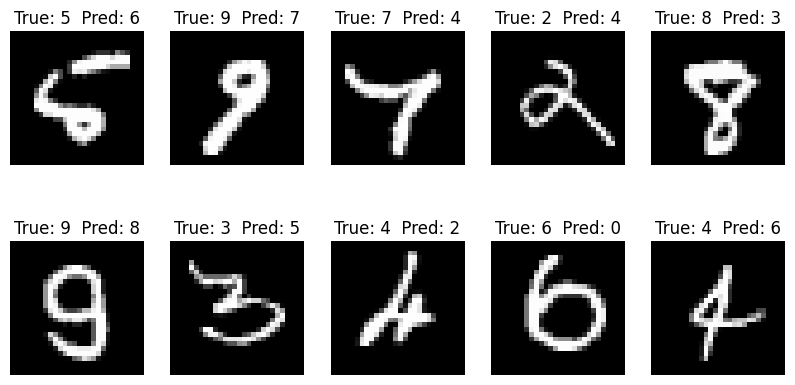

In [ ]:
errors = np.where(Ypredict != Ytest)[0]
print("Errors ::",len(errors))
plt.figure(figsize=(10,5))
for i in range(10):
    idx = errors[i]
    plt.subplot(2,5,i+1)
    plt.imshow(Xtest[idx].reshape(28,28), cmap='gray')
    plt.title(f"True: {Ytest[idx]}  Pred: {Ypredict[idx]}")
    plt.axis("off")
plt.show()